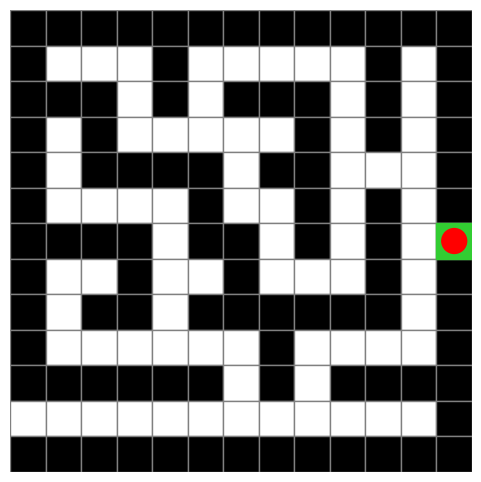

🎯 FINAL SUMMARY
----------------------
Start: (0, 11)
Goal: (12, 6)
Final Position: (12, 6)
Reached Goal: True
Total Steps: 192
Score: -80
Punishment: 154
Memory Size: 38


In [47]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
import time

maze = [
    [1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,1,0,0,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1,0,1],
    [1,0,1,1,1,1,0,1,1,0,0,0,1],
    [1,0,0,0,0,1,0,0,1,0,1,0,1],
    [1,1,1,1,0,1,1,0,1,0,1,0,0],
    [1,0,0,1,0,0,1,0,0,0,1,0,1],
    [1,0,1,1,0,1,1,1,1,1,1,0,1],
    [1,0,0,0,0,0,0,1,0,0,0,0,1],
    [1,1,1,1,1,1,0,1,0,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1]
]

ROWS = len(maze)
COLS = len(maze[0])

# START + GOAL
x, y = 0, 11
goal_x, goal_y = 12, 6

memory = set()
score = 0
punish = 0
steps = 0

directions = [(1,0),(-1,0),(0,1),(0,-1)]


# ---------------- DRAW FUNCTION ----------------
def draw(x, y):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,6))

    for r in range(ROWS):
        for c in range(COLS):
            color = "black" if maze[r][c] == 1 else "white"
            ax.add_patch(plt.Rectangle((c, ROWS-1-r), 1, 1, color=color, ec="gray"))

    # goal (green)
    ax.add_patch(plt.Rectangle((goal_x, ROWS-1-goal_y), 1, 1, color="limegreen"))

    # agent (red)
    ax.add_patch(plt.Circle((x+0.5, ROWS-1-y+0.5), 0.35, color="red"))

    ax.set_xlim(0, COLS)
    ax.set_ylim(0, ROWS)
    ax.set_aspect("equal")
    plt.axis("off")
    plt.show()


# ---------------- AI LOOP ----------------
for _ in range(500):
    steps += 1
    memory.add((x, y))

    # goal reached
    if (x, y) == (goal_x, goal_y):
        break

    random.shuffle(directions)

    moved = False

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < COLS and 0 <= ny < ROWS:

            if maze[ny][nx] == 1:
                continue

            if (nx, ny) not in memory:
                x, y = nx, ny
                score += 2
                moved = True
                break

    if not moved:
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < COLS and 0 <= ny < ROWS and maze[ny][nx] == 0:
                x, y = nx, ny
                score -= 1
                punish += 1
                break

    draw(x, y)
    time.sleep(0.1)


# ---------------- FINAL SUMMARY ONLY ----------------
print("🎯 FINAL SUMMARY")
print("----------------------")
print(f"Start: (0, 11)")
print(f"Goal: ({goal_x}, {goal_y})")
print(f"Final Position: ({x}, {y})")
print(f"Reached Goal: { (x, y) == (goal_x, goal_y) }")
print(f"Total Steps: {steps}")
print(f"Score: {score}")
print(f"Punishment: {punish}")
print(f"Memory Size: {len(memory)}")